In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv(r"C:\Users\LaptopDanielGMB\Downloads\Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [4]:
df = df.drop("CustomerID", axis=1)

encoder = LabelEncoder()
df["Gender"] = encoder.fit_transform(df["Gender"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

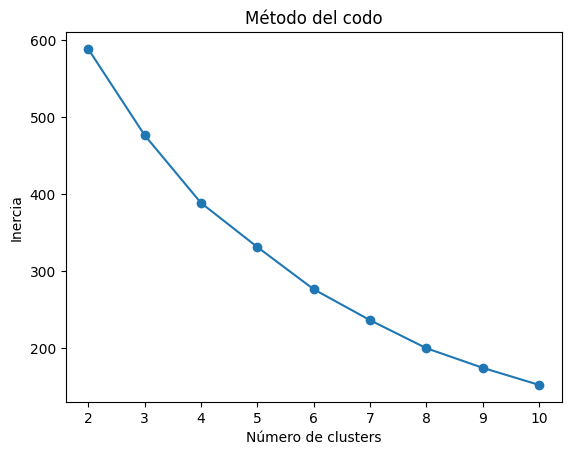

In [5]:
inertias = []
silhouettes = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

plt.plot(K, inertias, marker='o')
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.show()

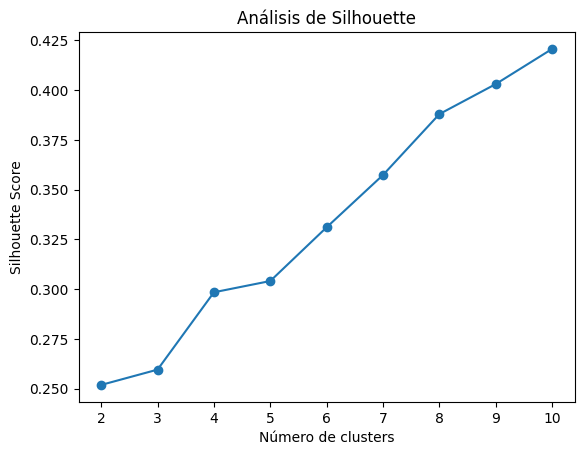

In [6]:
plt.plot(K, silhouettes, marker='o')
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette Score")
plt.title("Análisis de Silhouette")
plt.show()

In [7]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df["Cluster_KMeans"] = kmeans.fit_predict(X_scaled)

In [8]:
dbscan = DBSCAN(eps=0.9, min_samples=5)
df["Cluster_DBSCAN"] = dbscan.fit_predict(X_scaled)

df["Cluster_DBSCAN"].value_counts()

Cluster_DBSCAN
 1    110
 0     77
-1     13
Name: count, dtype: int64

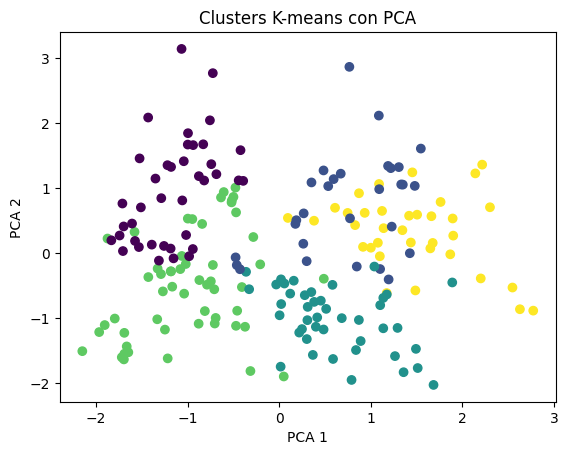

In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=df["Cluster_KMeans"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Clusters K-means con PCA")
plt.show()

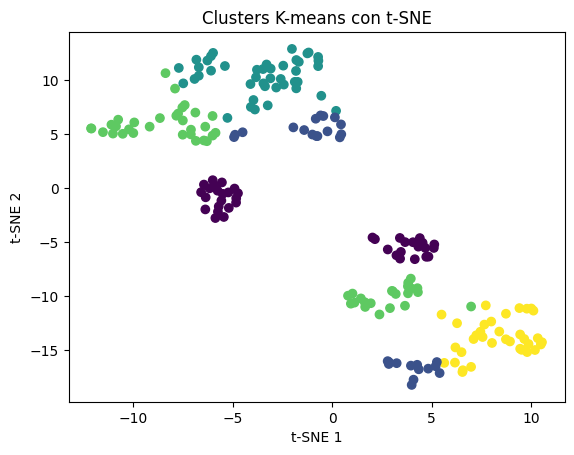

In [10]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=df["Cluster_KMeans"])
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("Clusters K-means con t-SNE")
plt.show()

In [11]:
cluster_summary = df.groupby("Cluster_KMeans").mean()
cluster_summary

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster_DBSCAN
Cluster_KMeans,,,,,
0,0.461538,32.692308,86.538462,82.128205,0.487179
1,0.448276,36.482759,89.517241,18.000000,0.413793
2,0.000000,49.813953,49.232558,40.069767,1.000000
3,0.407407,24.907407,39.722222,61.203704,0.518519
4,1.000000,55.714286,53.685714,36.771429,-0.142857
